<a href="https://colab.research.google.com/github/aryac-2006/Optional-Task---S-18/blob/main/used_car_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving car_web_scraped_dataset.csv to car_web_scraped_dataset.csv


In [ ]:
filepath = "./car_web_scraped_dataset.csv"

In [ ]:
df = pd.read_csv(filepath)

In [ ]:
# Display the first 5 rows
print("First 5 rows of the dataset:\n")
df.head(5)

First 5 rows of the dataset:



,name,year,miles,color,condition,price
0,Kia Forte,2022,"41,406 miles","Gray exterior, Black interior","No accidents reported, 1 Owner","$15,988"
1,Chevrolet Silverado 1500,2021,"15,138 miles","White exterior, Black interior","1 accident reported, 1 Owner","$38,008"
2,Toyota RAV4,2022,"32,879 miles","Silver exterior, Unknown interior","No accidents reported, 1 Owner","$24,988"
3,Honda Civic,2020,"37,190 miles","Blue exterior, Black interior","No accidents reported, 1 Owner","$18,998"
4,Honda Civic,2020,"27,496 miles","Black exterior, Black interior","No accidents reported, 1 Owner","$19,498"


In [ ]:
# Display the Last 5 rows
print("Last 5 rows of the dataset:\n")
df.tail(5)

Last 5 rows of the dataset:



,name,year,miles,color,condition,price
2835,Ford Escape,2013,"98,601 miles","Silver exterior, Unknown interior","2 accidents reported, 3 Owners","$8,995"
2836,Mercedes-Benz R-Class,2009,"120,694 miles","Black exterior, Black interior","1 accident reported, 3 Owners","$9,495"
2837,Mercedes-Benz GLC,2022,"27,894 miles","Gray exterior, Gray interior","No accidents reported, 2 Owners","$29,999"
2838,Honda CR-V,2021,"50,220 miles","Gray exterior, Unknown interior","No accidents reported, 1 Owner","$22,992"
2839,Honda Civic,2021,"26,510 miles","White exterior, Black interior","No accidents reported, 1 Owner","$24,135"


In [ ]:
# Shape of the data
print("1) Shape of the data (rows, columns):\n")
print(df.shape)

# Column names and data types (info())
print("\n2) Column names and data types:\n")
df.info()

# Statistical summary of numerical columns (describe())
print("\n3) Statistical summary of numerical columns:\n")
df.describe()

1) Shape of the data (rows, columns):

(2840, 6)

2) Column names and data types:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2840 entries, 0 to 2839
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   name       2840 non-null   object
 1   year       2840 non-null   int64 
 2   miles      2840 non-null   object
 3   color      2840 non-null   object
 4   condition  2840 non-null   object
 5   price      2840 non-null   object
dtypes: int64(1), object(5)
memory usage: 133.3+ KB

3) Statistical summary of numerical columns:



,year
count,2840.000000
mean,2018.833803
std,3.557585
min,2000.000000
25%,2017.000000
50%,2020.000000
75%,2021.000000
max,2024.000000


In [ ]:
# df.isnull().sum() :-
# Displays the number of missing values in each column

print("Null value in each column:\n")
df.isnull().sum()

Null value in each column:



,0
name,0
year,0
miles,0
color,0
condition,0
price,0


In [ ]:
# ======= numerical columns in the datase ========

print("Numerical Columns:")
print(df.select_dtypes(include="number").columns)

# select_dtypes() selects columns based on their data type.
# include = 'number' selects all numerical columns (such as int and float).
# .columns displays only the names of those columns.

# ======== categorical columns in the datase =======

print("\nCategorical Columns:")
print(df.select_dtypes(include="object").columns)

# include='object' selects all text (string) columns.

Numerical Columns:
Index(['year'], dtype='object')

Categorical Columns:
Index(['name', 'miles', 'color', 'condition', 'price'], dtype='object')


In [ ]:
print("Duplicate Rows:", df.duplicated().sum())

df = df.drop_duplicates()

print("After Removing Duplicates:", df.duplicated().sum())
print("shape:", df.shape)

Duplicate Rows: 528
After Removing Duplicates: 0
shape: (2312, 6)


In [ ]:
X = df.drop("price", axis=1)
y = df["price"]

print("-------------< Independent Features >-------------\n")
print(X.columns)
print("\n-------------< Dependent Features >-------------\n")
print(y.name)

-------------< Independent Features >-------------

Index(['name', 'year', 'miles', 'color', 'condition'], dtype='object')

-------------< Dependent Features >-------------

price


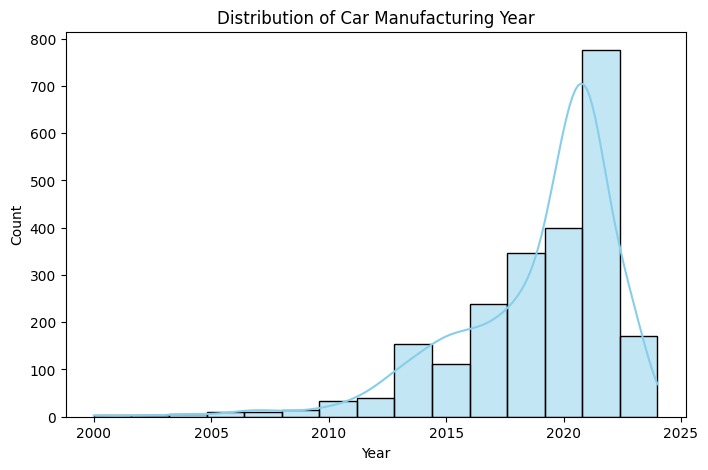

In [ ]:
# Histogram for Year
plt.figure(figsize=(8,5))
sns.histplot(df["year"], bins=15, kde=True, color="skyblue")

plt.title("Distribution of Car Manufacturing Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

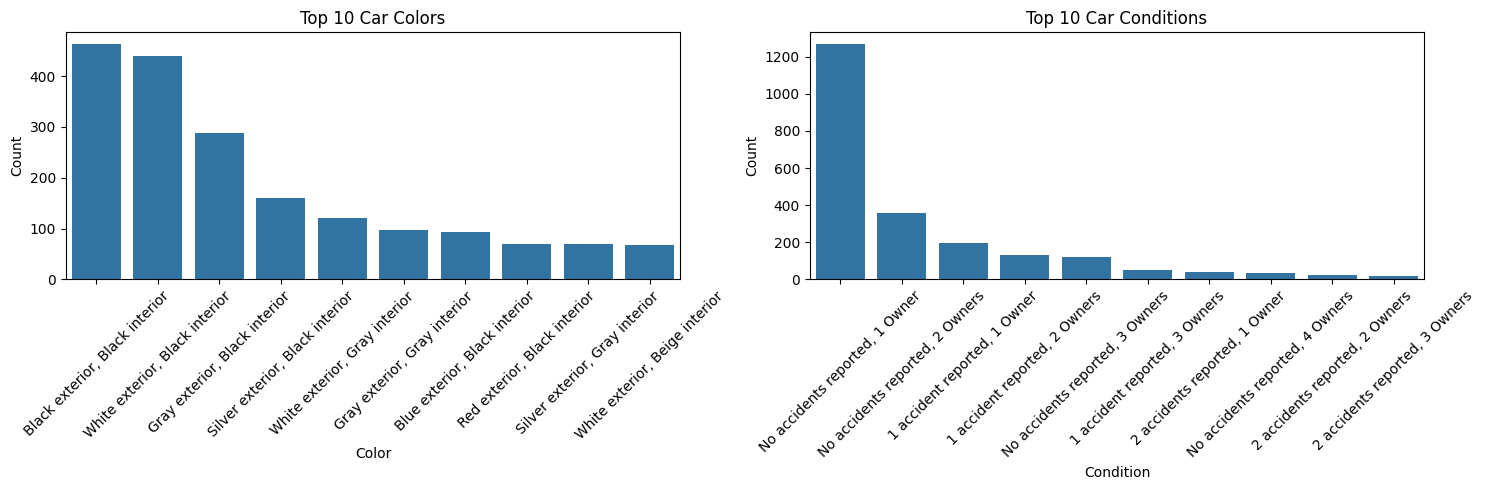

In [ ]:
plt.figure(figsize=(15,5))
# Top 10 Colors
plt.subplot(1,2,1)
top_colors = df["color"].value_counts().head(10).index
sns.countplot(data=df, x="color", order=top_colors)
plt.title("Top 10 Car Colors")
plt.xlabel("Color")
plt.ylabel("Count")
plt.xticks(rotation=45)

# Top 10 Conditions
plt.subplot(1,2,2)
top_conditions = df["condition"].value_counts().head(10).index
sns.countplot(data=df, x="condition", order=top_conditions)
plt.title("Top 10 Car Conditions")
plt.xlabel("Condition")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

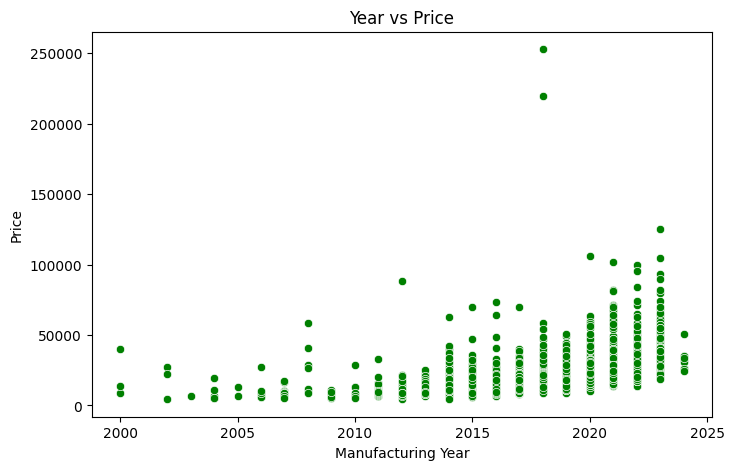

In [ ]:
df["price"] = df["price"].replace(r"[$,]", "", regex=True)
df["price"] = pd.to_numeric(df["price"], errors="coerce")

plt.figure(figsize=(8,5))

sns.scatterplot(x="year", y="price", data=df, color="green")
plt.title("Year vs Price")
plt.xlabel("Manufacturing Year")
plt.ylabel("Price")

plt.show()

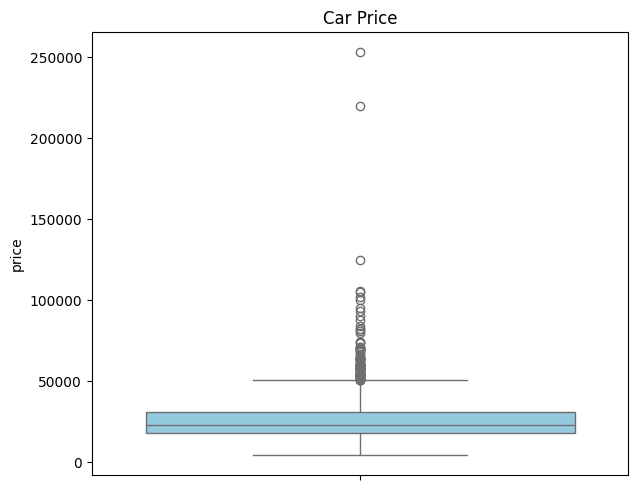

In [ ]:

plt.figure(figsize=(12,5))
# Price
plt.subplot(1,2,1)
sns.boxplot(y="price", data=df, color="skyblue")
plt.title("Car Price")

plt.tight_layout()
plt.show()

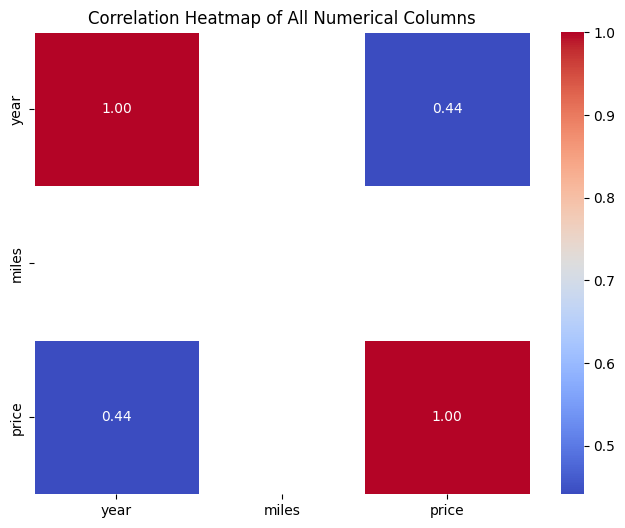

In [ ]:
# Select all numerical columns
numeric_df = df.select_dtypes(include=["number"])

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Heatmap of All Numerical Columns")
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

# Select numerical features
X = df[["year", "miles"]]

# Initialize scaler
scaler = StandardScaler()

# Apply feature scaling
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame
import pandas as pd
X_scaled = pd.DataFrame(X_scaled, columns=["year", "miles"])

print(X_scaled.head())

       year  miles
0  0.901979    NaN
1  0.613465    NaN
2  0.901979    NaN
3  0.324952    NaN
4  0.324952    NaN


/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count
